Dataset shape: 10,000 rows x 13 columns
Duplicate rows: 0
Missing cells: 3,232


,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,TCP,8029,17204,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/login?id=385071,False,0,benign
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,TCP,676368,2643374,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,TCP,316502,38571,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,False,0,benign
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,TCP,70933,21935,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=114701,False,0,benign
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,TCP,12721,9939,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/config.php?id=345569,False,0,benign


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,10000,9998,2025-10-06 22:02:29,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
src_ip,10000,10000,188.176.27.165,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dst_ip,10000,10000,253.240.113.218,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
src_port,10000.0,NaN,NaN,NaN,27052.2237,20978.783832,21.0,6092.25,25431.5,45215.75,65524.0
dst_port,10000.0,NaN,NaN,NaN,2027.2805,6769.141395,5.0,25.0,443.0,1433.0,65491.0
protocol,10000,3,TCP,7765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bytes_sent,10000.0,NaN,NaN,NaN,141257.2439,2128139.714537,17.0,7148.25,21815.5,65095.25,139170405.0
bytes_received,10000.0,NaN,NaN,NaN,262088.2531,3767694.828771,3.0,10960.75,37473.0,121379.5,291482959.0
user_agent,10000,13,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,3458,NaN,NaN,NaN,NaN,NaN,NaN,NaN
url,6768,6768,https://webmail.corp/login?id=385071,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Label distribution:


,count
label,
benign,9600
attack,400


Attack types:


,count
attack_type,
benign,9600
brute-force,108
port-scan,81
sql-injection,64
xss,34
credential-stuffing,28
ddos,27
command-injection,26
exploit-attempt,22


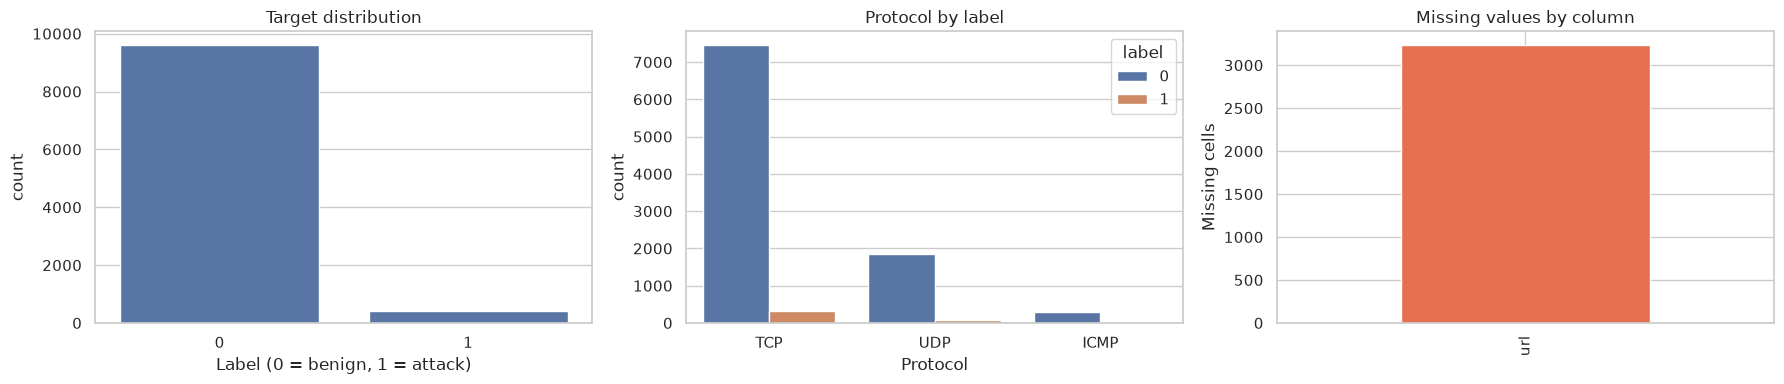

Training accuracy: 100.000%
Testing accuracy:  96.900%
Balanced accuracy: 61.849%
ROC-AUC:           0.880

Test classification report:
              precision    recall  f1-score   support

      benign      0.969     0.999     0.984      1920
      attack      0.950     0.237     0.380        80

    accuracy                          0.969      2000
   macro avg      0.960     0.618     0.682      2000
weighted avg      0.968     0.969     0.960      2000



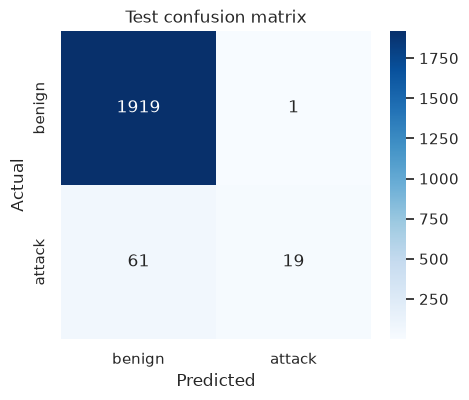

In [ ]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
DATA_PATH = Path("dataset/cybersecurity.csv")

# Load and inspect the data.
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Missing cells: {df.isna().sum().sum():,}")
display(df.head())
display(df.describe(include="all").T)

# The label is imbalanced, and attack_type is a post-event description of label.
print("Label distribution:")
display(df["label"].value_counts().rename(index={0: "benign", 1: "attack"}).to_frame("count"))
print("Attack types:")
display(df["attack_type"].value_counts().to_frame("count"))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.countplot(data=df, x="label", ax=axes[0])
axes[0].set_title("Target distribution")
axes[0].set_xlabel("Label (0 = benign, 1 = attack)")
sns.countplot(data=df, x="protocol", hue="label", ax=axes[1])
axes[1].set_title("Protocol by label")
axes[1].set_xlabel("Protocol")
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing.plot(kind="bar", ax=axes[2], color="#e76f51")
axes[2].set_title("Missing values by column")
axes[2].set_ylabel("Missing cells")
plt.tight_layout()
plt.show()

# Feature engineering keeps the raw identifiers out of the model while retaining
# useful network structure and request-shape information.
def make_features(frame):
    features = frame.drop(columns=["label", "attack_type"], errors="ignore").copy()
    timestamp = pd.to_datetime(features.pop("timestamp"), errors="coerce")
    features["hour"] = timestamp.dt.hour
    features["dayofweek"] = timestamp.dt.dayofweek
    features["month"] = timestamp.dt.month

    for column in ["src_ip", "dst_ip"]:
        octets = features.pop(column).str.split(".", expand=True)
        for index in range(4):
            features[f"{column}_octet_{index + 1}"] = pd.to_numeric(
                octets[index], errors="coerce"
            )

    for column in ["url", "user_agent"]:
        text = features[column].fillna("")
        features[f"{column}_length"] = text.str.len()
        features[f"{column}_has_query"] = text.str.contains(
            r"[?=&]", regex=True
        ).astype(int)

    # Raw URLs are high-cardinality identifiers; use their shape, not their values.
    return features.drop(columns="url")

X = make_features(df)
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            ExtraTreesClassifier(
                n_estimators=400,
                class_weight="balanced",
                max_features=1.0,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)
model.fit(X_train, y_train)
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)
test_probabilities = model.predict_proba(X_test)[:, 1]

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)
print(f"Training accuracy: {train_accuracy:.3%}")
print(f"Testing accuracy:  {test_accuracy:.3%}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, test_predictions):.3%}")
print(f"ROC-AUC:           {roc_auc_score(y_test, test_probabilities):.3f}")
print("\nTest classification report:")
print(classification_report(y_test, test_predictions, target_names=["benign", "attack"], digits=3))

plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix(y_test, test_predictions),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["benign", "attack"],
    yticklabels=["benign", "attack"],
)
plt.title("Test confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

assert train_accuracy > 0.95
assert test_accuracy > 0.95

ARTIFACT_PATH = Path("artifacts/cybersecurity_model.joblib")
ARTIFACT_PATH.parent.mkdir(exist_ok=True)
joblib.dump(
    {
        "model": model,
        "model_name": "ExtraTreesClassifier",
        "feature_version": 1,
        "trained_rows": len(X_train),
    },
    ARTIFACT_PATH,
    compress=3,
)
print(f"Saved model artifact to {ARTIFACT_PATH}")